# Correcting for Template Changes in ATLAS Light Curves

This notebook takes into account ATLAS's periodic replacement of the difference image reference templates, which may cause step discontinuities in flux. Two template changes have been recorded at MJDs 58417 and 58882. More information can be found here: https://fallingstar-data.com/forcedphot/faq/.

We aid the user in adding offset flux to different regions of the ATLAS light curve in order to correct for these step discontinuities.

In order for this notebook to work correctly, the ATLAS light curves must already be downloaded and saved. Each light curve must also only include measurements for a single filter. To download SN and control light curves, please refer to the documentation `README.md` and use the download script `download_atlas_lc.py`.

## Settings

<div class="alert alert-block alert-info">
    <b>Tip:</b> Edit the following settings to correspond to your target SN and source directory for data.
</div>


Below we have set example fields for SN 2018gkr. Recommended fields to change at a minimum include `tnsname`, `source_dir`, and `discovery_date`.

In [1]:
##### LOADING THE SN LIGHT CURVE #####

# Enter the target SN name:
tnsname = '2023zkd'

# Enter the path to the data directory that contains the SN directories:
source_dir = f'/Users/sofiarest/Desktop/Supernovae/data_refactor/atclean_input' 

# Enter the path to a directory to optionally save any plots:
output_dir = f'/Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/{tnsname}/plots'

# Enter the filter for this light curve:
filt = 'o'

# Enter the SN's discovery date:
discovery_date = 60112.192000

##### LOADING CONTROL LIGHT CURVES #####

# Set to True if you are planning on applying the control light curve cut 
# and have already downloaded the control light curves:
load_controls = True

# Enter the number of control light curves to load:
num_controls = 8

# Enter the source directory of the control light curve files:
controls_dir = f'{source_dir}/{tnsname}/controls'

##### PLOTTING #####

# If True, try to calculate the best y limits automatically for each plot;
# if False, leave y limits to matplotlib 
auto_xylimits = True

In [2]:
import sys, os
import numpy as np
from copy import deepcopy
import pandas as pd

sys.path.insert(1,'../')
from lightcurve import Supernova, LightCurve, AorB, PresetColumnNames
from plot import Plot, PlotLimits
from download import load_config

## Load the SN ATLAS light curve

In [3]:
print(f'SN {tnsname}, filter {filt}, {num_controls} control light curves')
if not discovery_date is None:
    print(f'SN discovery date: {discovery_date}')
print(f'Source directory (load SN light curve): {source_dir}/{tnsname}')
if load_controls: 
    print(f'Controls directory (load control light curves): {controls_dir}')
print(f'Output directory (save plots): {output_dir}')
print(f'Config file path: ./config.ini')

SN 2023zkd, filter o, 8 control light curves
SN discovery date: 60112.192
Source directory (load SN light curve): /Users/sofiarest/Desktop/Supernovae/data_refactor/atclean_input/2023zkd
Controls directory (load control light curves): /Users/sofiarest/Desktop/Supernovae/data_refactor/atclean_input/2023zkd/controls
Output directory (save plots): /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2023zkd/plots
Config file path: ./config.ini


In [4]:
# load config
config = load_config('config.ini')

# load preset
print(f"Loading ATLAS preset column names from config.ini...")
colnames = PresetColumnNames(config, "atlas")
print(colnames.__str__())
print("Success")

print("\nLoading SN light curve...")
lc = LightCurve(colnames)
lc.load_lc(source_dir, tnsname, cleaned=False)
print("Success")

p = Plot(output_dir)


Loading config file at config.ini...
Loading ATLAS preset column names from config.ini...
--- Required Columns ---
mjd: MJD
flux: uJy
dflux: duJy
--- Optional Columns ---
chisquare: chi/N
filt: F
mag: m
dmag: dm
ra: RA
dec: Dec
--- Extra Columns to Copy ---
x, y, maj, min, phi, apfit, mag5sig, Sky, Obs
Success

Loading SN light curve...
Success


In [5]:
# Optionally, manually enter the x and y limits for the plot:
xlim_lower = None
xlim_upper = None
ylim_lower = None
ylim_upper = None

            MJD       m     dm  uJy  duJy  F  err  chi/N         RA      Dec        x        y   maj   min   phi  apfit  mag5sig    Sky             Obs
0  57230.267141  21.203  4.312   12    52  o    0   1.05  237.19811  9.20004  2955.95  8405.18  3.63  3.55   9.8 -0.418    18.51  19.53  02a57230o0033o
1  57230.276657 -20.946  3.263  -15    50  o    0   1.05  237.19811  9.20004  2954.48  8406.59  3.79  3.67  -8.2 -0.409    18.47  19.53  02a57230o0044o
2  57230.301745  21.765  6.444    7    46  o    0   0.99  237.19811  9.20004  1494.40  9889.15  3.72  3.51 -13.4 -0.464    18.49  19.48  02a57230o0078o
3  57230.304669  20.298  1.571   28    43  o    0   0.86  237.19811  9.20004  7747.03   194.15  3.75  3.53 -76.2 -0.436    18.52  19.55  02a57230o0082o
4  57230.318656 -19.578  0.833  -54    45  o    0   0.88  237.19811  9.20004  7739.35   198.90  3.67  3.61 -35.5 -0.478    18.54  19.56  02a57230o0099o
Saving plot: /Users/sofiarest/Desktop/Supernovae/data_refactor/output/misc/2023zkd/plots

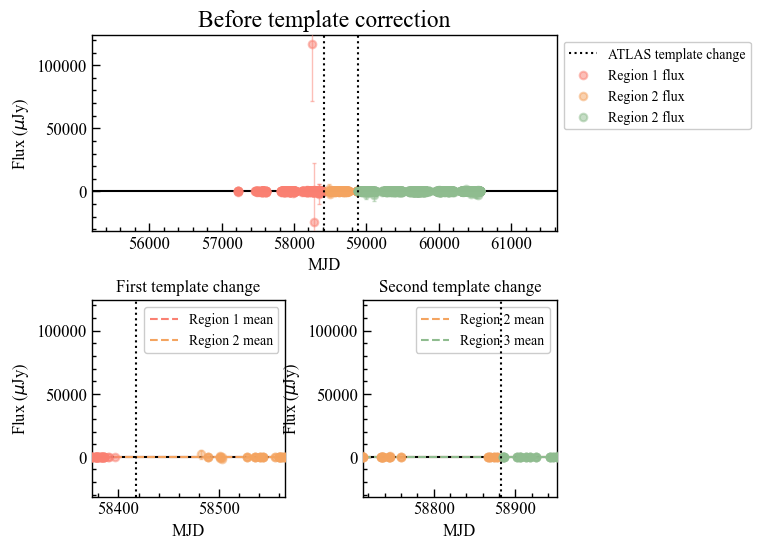

In [7]:
custom_lims = PlotLimits(
    xlower=xlim_lower,
    xupper=xlim_upper,
    ylower=ylim_lower,
    yupper=ylim_upper,
)

print(lc.t.head().to_string())

fig = p.plot_template_correction(
    lc, 
    p.get_lims(lc=lc, custom_lims=custom_lims), 
    title="Before template correction", 
    save=True, 
    filename="before_template_correction"
)

In [8]:
# Optionally enter flux offsets for each region 
# (set each to None for automatic correction):
global_offset = 350
region1_offset = 0 + global_offset
region2_offset = 50 + global_offset
region3_offset = -50 + global_offset

# Optionally, manually enter the x and y limits for the plot:
xlim_lower = None
xlim_upper = None
ylim_lower = None
ylim_upper = None

In [ ]:
# TODO